In [1]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset (1) (1).csv to placement_predict_50k Dataset (1) (1).csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
import os

print(os.listdir('/content'))

['.config', 'placement_predict_50k Dataset (1) (1).csv', 'sample_data']


In [6]:
import pandas as pd

filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

df = pd.read_csv(filename)

print("Dataset shape:", df.shape)

df.head()

Uploaded file: placement_predict_50k Dataset (1) (1).csv
Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [7]:
df = df.drop(
    columns=["IsAnomaly"],
    errors="ignore"
)

print("IsAnomaly column removed.")
print("New shape:", df.shape)

IsAnomaly column removed.
New shape: (50000, 31)


In [8]:
for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(
            df[col].median()
        )

    else:
        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

print(
    "Missing values remaining:",
    df.isnull().sum().sum()
)

Missing values remaining: 0


In [9]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "City",
        "CollegeTier",
        "Stream",
        "Specialisation",
        "Hostel",
        "HistoryOfBacklogs",
        "ExtraCurricular"
    ],
    drop_first=True
)

print(
    "Encoded dataset shape:",
    df_encoded.shape
)

Encoded dataset shape: (50000, 46)


In [10]:
X = df_encoded.drop(
    columns=["PlacementStatus"]
)

y = df_encoded[
    "PlacementStatus"
]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (50000, 45)
y shape: (50000,)

Target distribution:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

Training samples: 40000
Testing samples: 10000


In [13]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "City",
        "CollegeTier",
        "Stream",
        "Specialisation",
        "Hostel",
        "HistoryOfBacklogs",
        "ExtraCurricular",
        "CGPA_Tier"
    ],
    drop_first=True
)

print("Encoded dataset shape:", df_encoded.shape)

Encoded dataset shape: (50000, 47)


In [14]:
X = df_encoded.drop(
    columns=["PlacementStatus"]
)

y = df_encoded["PlacementStatus"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 46)
y shape: (50000,)


In [15]:
print("Remaining text columns:")
print(X.select_dtypes(include=["object", "category"]).columns.tolist())

Remaining text columns:
[]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 40000
Testing samples: 10000


In [17]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [18]:
y_pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3422
           1       1.00      1.00      1.00      6578

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



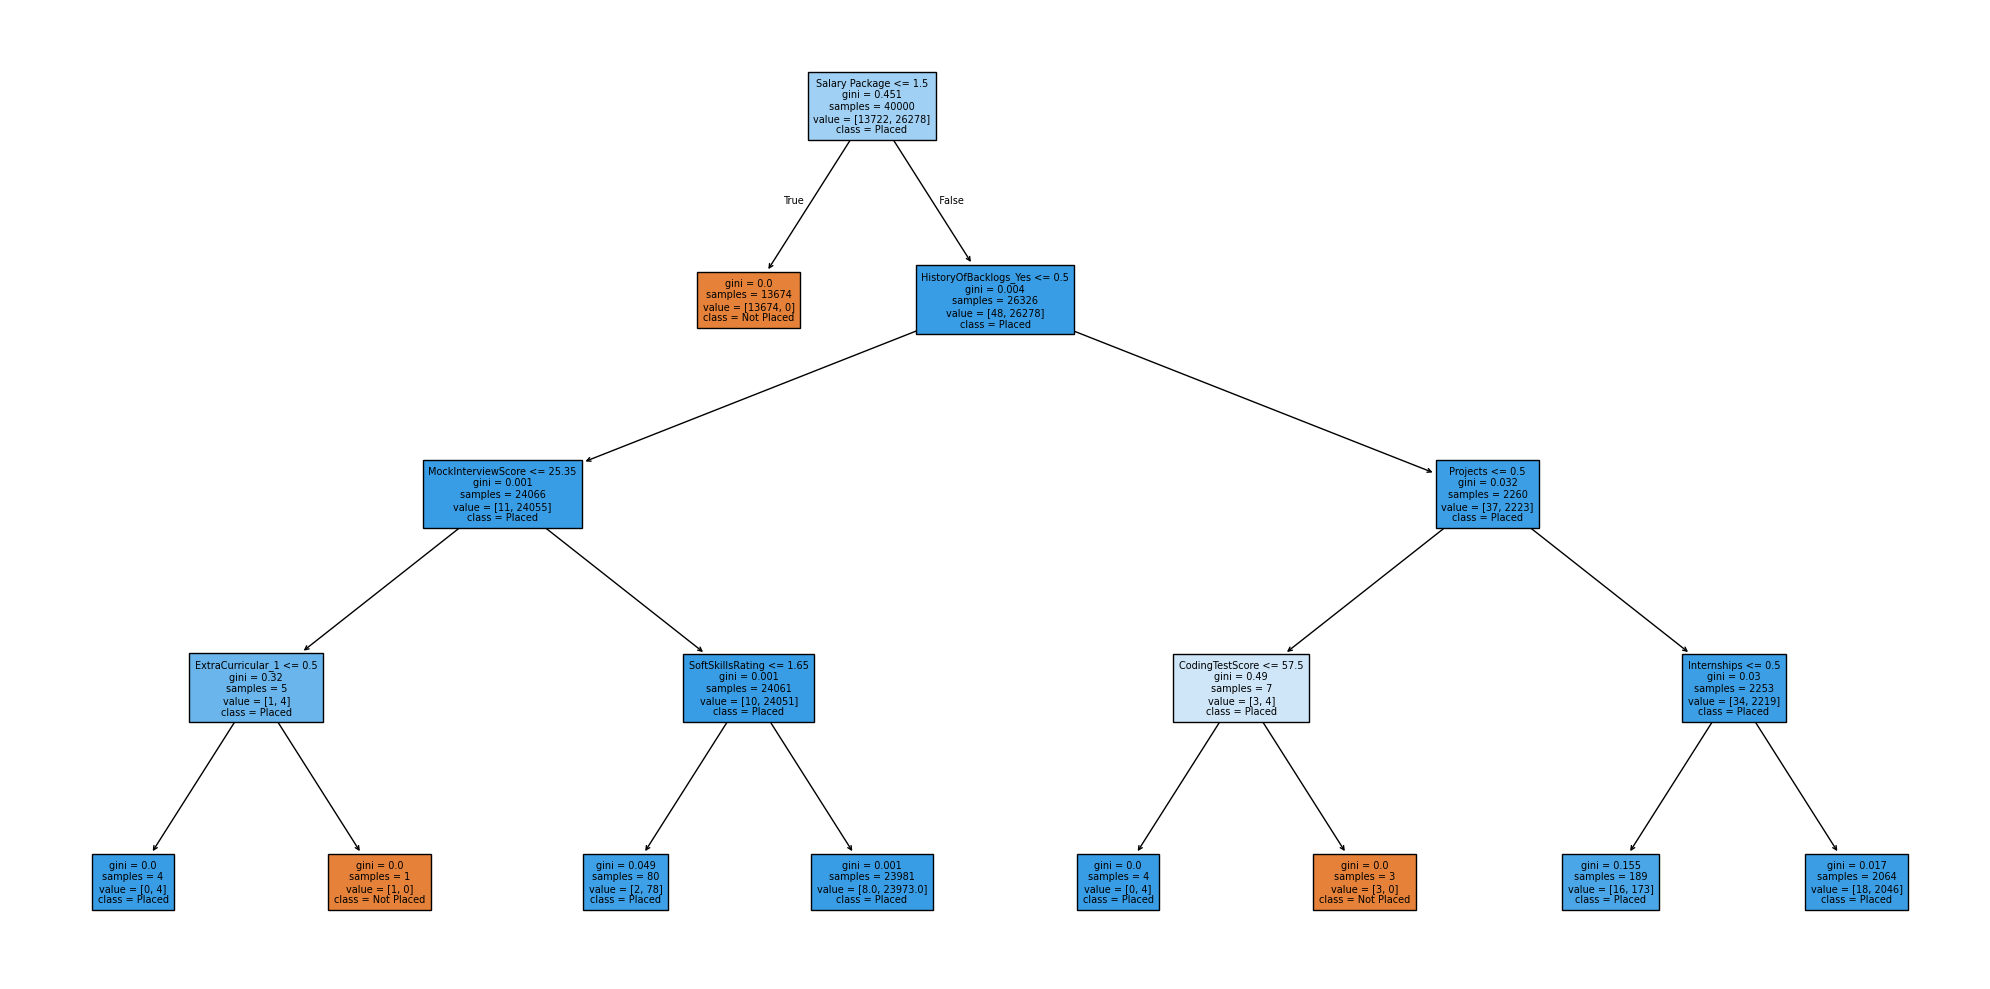

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    fontsize=7
)

plt.tight_layout()
plt.show()

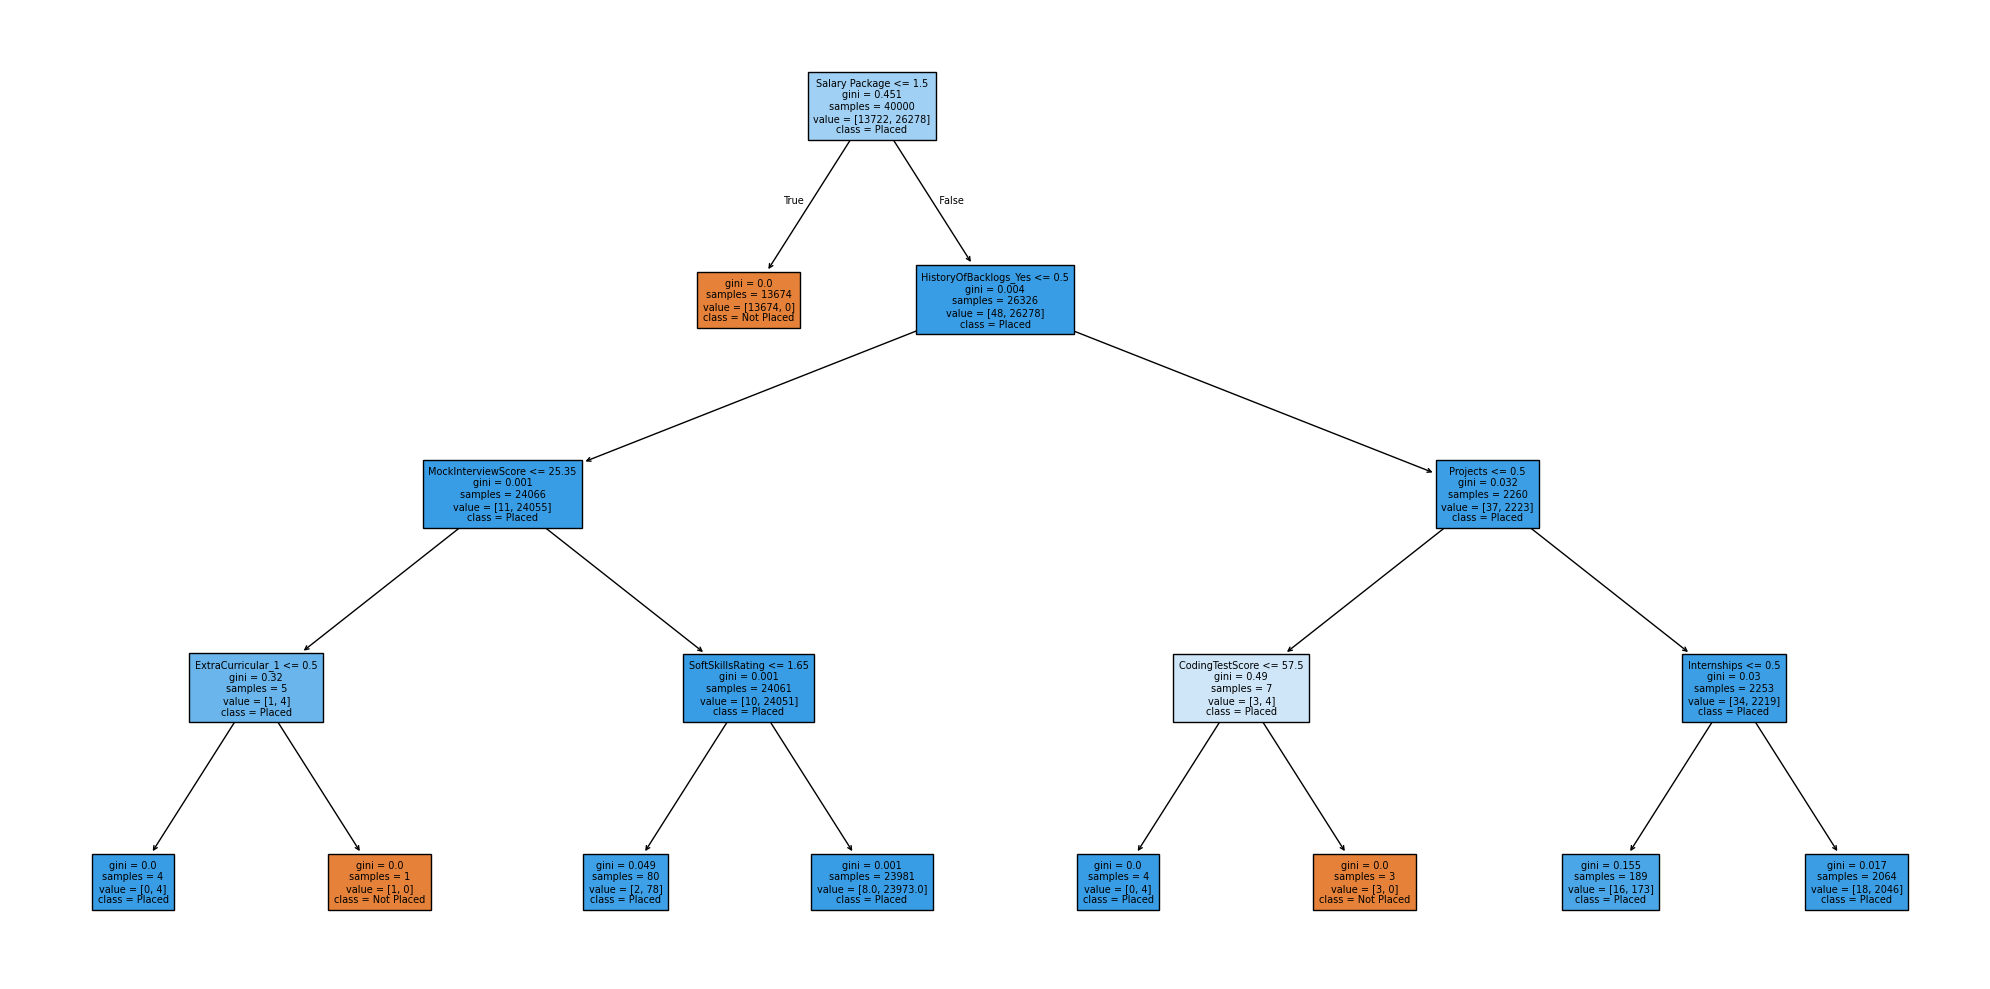

Saved tree image.


In [20]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    fontsize=7
)

plt.tight_layout()

plt.savefig(
    "decision_tree.png",
    dpi=150
)

plt.show()

print("Saved tree image.")

In [21]:
from google.colab import files

uploaded_rf = files.upload()

Saving simple_placement_dataset.csv to simple_placement_dataset.csv


In [22]:
filename_rf = list(uploaded_rf.keys())[0]

print("Uploaded file:", filename_rf)

df_rf = pd.read_csv(filename_rf)

print("Dataset shape:", df_rf.shape)

df_rf.head()

Uploaded file: simple_placement_dataset.csv
Dataset shape: (50000, 13)


,StudentID,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,Placed
0,1,6.29,73.3,1,2,2.0,2,0,66.7,2.2,49.4,47.8,0
1,2,5.23,54.5,0,1,0.0,1,0,48.2,2.4,26.7,25.8,0
2,3,5.52,77.6,1,3,1.0,1,0,73.8,2.8,67.7,41.5,1
3,4,7.51,68.8,1,2,1.0,2,0,69.8,2.7,66.9,48.0,1
4,5,8.65,95.8,2,3,2.0,4,1,73.1,2.1,71.7,61.7,1


In [23]:
print("Class balance:")
print(df_rf["Placed"].value_counts())

Class balance:
Placed
1    32856
0    17144
Name: count, dtype: int64


In [24]:
TARGET = "Placed"

DROP_COLS = [
    "StudentID"
]

feature_names = [
    c for c in df_rf.columns
    if c not in [TARGET] + DROP_COLS
]

X_rf = df_rf[feature_names].values
y_rf = df_rf[TARGET].values

print("Features used:")
print(feature_names)

print("\nNumber of features:", len(feature_names))

Features used:
['CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']

Number of features: 11


In [25]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train_rf.shape[0])
print("Testing samples:", X_test_rf.shape[0])

Training samples: 40000
Testing samples: 10000


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE
)

rf.fit(
    X_train_rf,
    y_train_rf
)

print("Random Forest trained successfully.")


Random Forest trained successfully.


In [27]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = rf.predict(
    X_test_rf
)

test_accuracy = accuracy_score(
    y_test_rf,
    y_pred_rf
)

print(f"OOB score: {rf.oob_score_:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_rf,
        y_pred_rf
    )
)

OOB score: 0.9088
Test accuracy: 0.9099

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      3422
           1       0.92      0.95      0.93      6578

    accuracy                           0.91     10000
   macro avg       0.90      0.89      0.90     10000
weighted avg       0.91      0.91      0.91     10000



In [28]:
print("Feature importances:")

for name, importance in sorted(
    zip(
        feature_names,
        rf.feature_importances_
    ),
    key=lambda x: -x[1]
):

    print(
        f"{name}: {importance:.4f}"
    )

Feature importances:
CGPA: 0.2907
MockInterviewScore: 0.1740
CodingTestScore: 0.1471
Projects: 0.0888
AptitudeTestScore: 0.0854
SoftSkillsRating: 0.0783
AttendancePercent: 0.0552
Internships: 0.0326
Certifications: 0.0260
Workshops: 0.0137
Publications: 0.0081
